# Análisis de resultados - Simulación Mundial 2026

Este notebook visualiza los resultados de la simulación Monte Carlo (`output/resultados.csv`)
generada por `src/simulate.py`: probabilidad de cada selección de pasar de grupo,
llegar a octavos (8vos), cuartos (4tos), semifinal, final y ser campeona.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE_DIR = Path.cwd().parent
OUTPUT_DIR = BASE_DIR / "output"

resultados = pd.read_csv(OUTPUT_DIR / "resultados.csv")
resultados = resultados.sort_values("prob_campeon", ascending=False).reset_index(drop=True)
resultados.head()

,seleccion,grupo,elo,prob_pasa_grupo,prob_llega_8vos,prob_llega_4tos,prob_llega_semis,prob_llega_final,prob_campeon
0,Argentina,J,2026.7,0.9846,0.7701,0.5917,0.4383,0.3451,0.2398
1,Spain,H,2000.1,0.9907,0.7528,0.5523,0.3932,0.2788,0.1692
2,Brazil,C,1947.4,0.9368,0.7074,0.4921,0.3327,0.1727,0.0862
3,England,L,1914.8,0.9713,0.6692,0.4221,0.1949,0.1160,0.0624
4,France,I,1976.2,0.9353,0.5727,0.2959,0.1809,0.1115,0.0578


## Tabla de probabilidades (ordenada por probabilidad de campeón)

In [2]:
columnas_prob = [
    "prob_pasa_grupo", "prob_llega_8vos", "prob_llega_4tos",
    "prob_llega_semis", "prob_llega_final", "prob_campeon",
]

tabla = resultados.set_index("seleccion")[["grupo", "elo"] + columnas_prob].copy()
tabla_pct = tabla.copy()
tabla_pct[columnas_prob] = (tabla_pct[columnas_prob] * 100).round(1)

tabla_pct.style.format({c: "{:.1f}%" for c in columnas_prob}).background_gradient(
    subset=columnas_prob, cmap="YlOrRd"
)

,grupo,elo,prob_pasa_grupo,prob_llega_8vos,prob_llega_4tos,prob_llega_semis,prob_llega_final,prob_campeon
seleccion,,,,,,,,
Argentina,J,2026.700000,98.5%,77.0%,59.2%,43.8%,34.5%,24.0%
Spain,H,2000.100000,99.1%,75.3%,55.2%,39.3%,27.9%,16.9%
Brazil,C,1947.400000,93.7%,70.7%,49.2%,33.3%,17.3%,8.6%
England,L,1914.800000,97.1%,66.9%,42.2%,19.5%,11.6%,6.2%
France,I,1976.200000,93.5%,57.3%,29.6%,18.1%,11.2%,5.8%
Belgium,G,1879.400000,93.6%,60.0%,30.8%,17.1%,9.4%,4.4%
Portugal,K,1914.900000,90.0%,50.9%,28.6%,13.5%,7.5%,3.7%
Ecuador,E,1889.300000,94.6%,62.1%,35.7%,18.0%,8.5%,3.6%
Colombia,K,1913.200000,88.0%,48.5%,27.1%,12.5%,6.7%,3.3%


## Top 15 candidatos al título

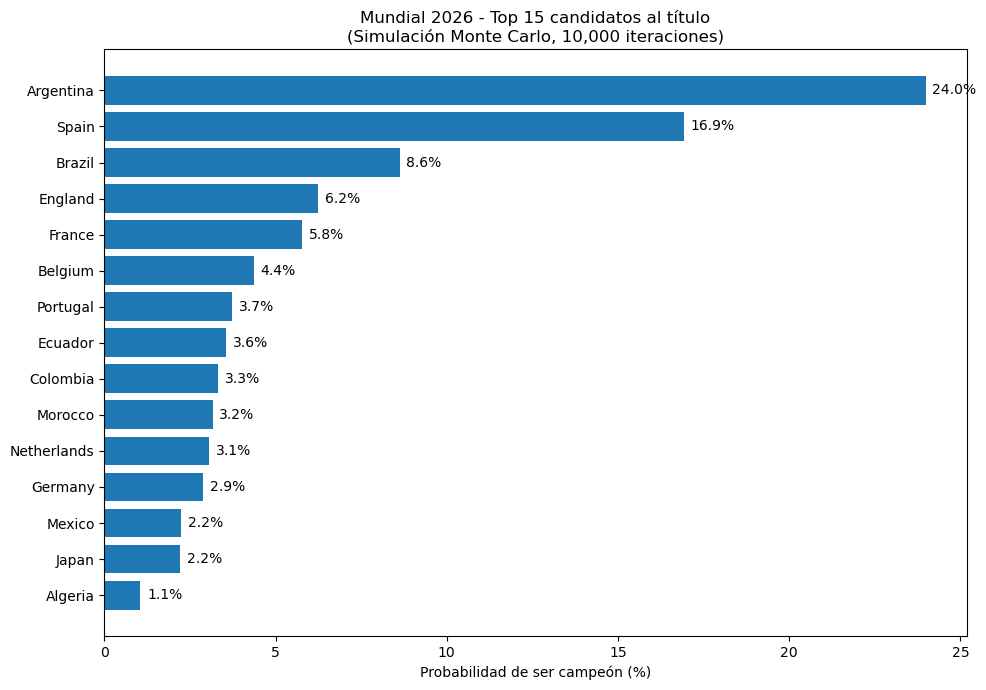

In [3]:
top15 = resultados.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15["seleccion"], top15["prob_campeon"] * 100, color="#1f77b4")
ax.set_xlabel("Probabilidad de ser campeón (%)")
ax.set_title("Mundial 2026 - Top 15 candidatos al título\n(Simulación Monte Carlo, 10,000 iteraciones)")
ax.invert_yaxis()  # el equipo con mayor probabilidad arriba

for i, valor in enumerate(top15["prob_campeon"] * 100):
    ax.text(valor + 0.2, i, f"{valor:.1f}%", va="center")

plt.tight_layout()
plt.show()

## Heatmap de probabilidades por ronda (Top 15)

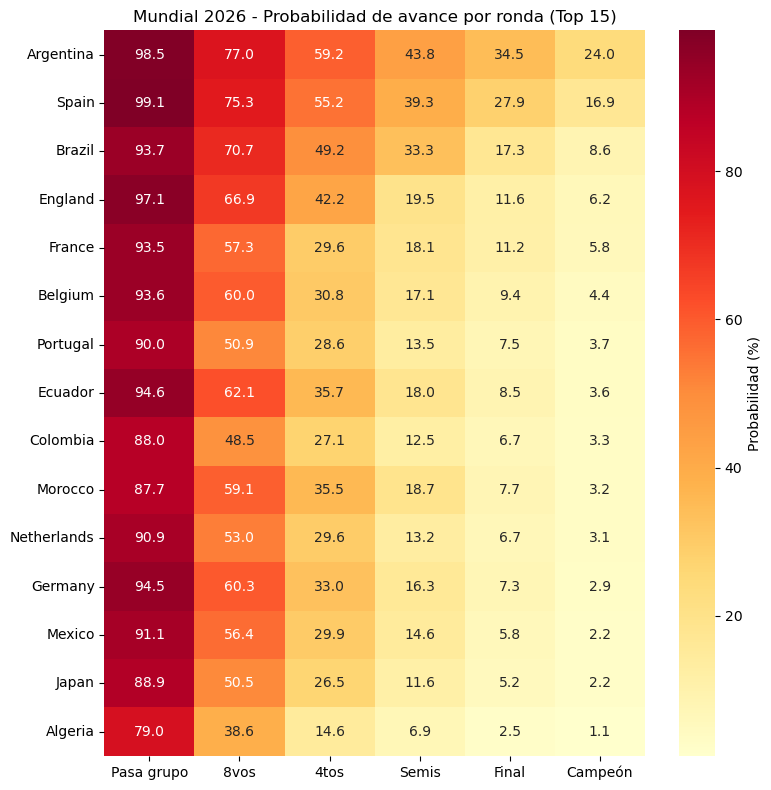

In [4]:
etiquetas_rondas = ["Pasa grupo", "8vos", "4tos", "Semis", "Final", "Campeón"]

datos_heatmap = top15.set_index("seleccion")[columnas_prob] * 100
datos_heatmap.columns = etiquetas_rondas

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    datos_heatmap, annot=True, fmt=".1f", cmap="YlOrRd",
    cbar_kws={"label": "Probabilidad (%)"}, ax=ax,
)
ax.set_title("Mundial 2026 - Probabilidad de avance por ronda (Top 15)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Bonus: resumen para WhatsApp

Genera un texto plano con emojis, listo para compartir con el equipo,
y lo guarda en `output/resumen_whatsapp.txt`.

In [5]:
top10 = resultados.head(10)
emojis_posicion = ["🥇", "🥈", "🥉", "4️⃣", "5️⃣", "6️⃣", "7️⃣", "8️⃣", "9️⃣", "🔟"]

lineas = []
lineas.append("🏆 *MUNDIAL 2026 - TOP 10 FAVORITOS* 🏆")
lineas.append("_Simulación Monte Carlo - 10,000 torneos_")
lineas.append("")

for i, (_, fila) in enumerate(top10.iterrows()):
    lineas.append(f"{emojis_posicion[i]} *{fila['seleccion']}* — {fila['prob_campeon'] * 100:.1f}% de ser campeón")

lineas.append("")
lineas.append("⚽ ¡Que gane el mejor! ⚽")

resumen = "\n".join(lineas)
print(resumen)

with open(OUTPUT_DIR / "resumen_whatsapp.txt", "w", encoding="utf-8") as f:
    f.write(resumen)

🏆 *MUNDIAL 2026 - TOP 10 FAVORITOS* 🏆
_Simulación Monte Carlo - 10,000 torneos_

🥇 *Argentina* — 24.0% de ser campeón
🥈 *Spain* — 16.9% de ser campeón
🥉 *Brazil* — 8.6% de ser campeón
4️⃣ *England* — 6.2% de ser campeón
5️⃣ *France* — 5.8% de ser campeón
6️⃣ *Belgium* — 4.4% de ser campeón
7️⃣ *Portugal* — 3.7% de ser campeón
8️⃣ *Ecuador* — 3.6% de ser campeón
9️⃣ *Colombia* — 3.3% de ser campeón
🔟 *Morocco* — 3.2% de ser campeón

⚽ ¡Que gane el mejor! ⚽


## Consulta interactiva: predicción de un partido

Usa `src/predecir_partido.py` para consultar goles esperados, probabilidad de Victoria/Empate/Derrota y los marcadores más probables de cualquier cruce entre selecciones del Mundial 2026 (fase de grupos o eliminatorias).

In [6]:
import sys
sys.path.append(str(BASE_DIR / "src"))

from predecir_partido import cargar_recursos, predecir_partido, imprimir_prediccion

estado, modelo, rho = cargar_recursos()

# Cambia aquí los equipos para consultar cualquier partido
pred = predecir_partido("Brazil", "Germany", estado, modelo, rho, neutral=True)
imprimir_prediccion(pred)


Brazil vs Germany
Goles esperados: 1.42 - 1.10
P(gana Brazil):   44.0%
P(empate):               26.9%
P(gana Germany):  29.1%
Marcadores más probables:
   1-1: 12.8%
   1-0: 11.2%
   2-1:  8.9%
   0-1:  8.6%
   0-0:  8.3%
